# Common Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

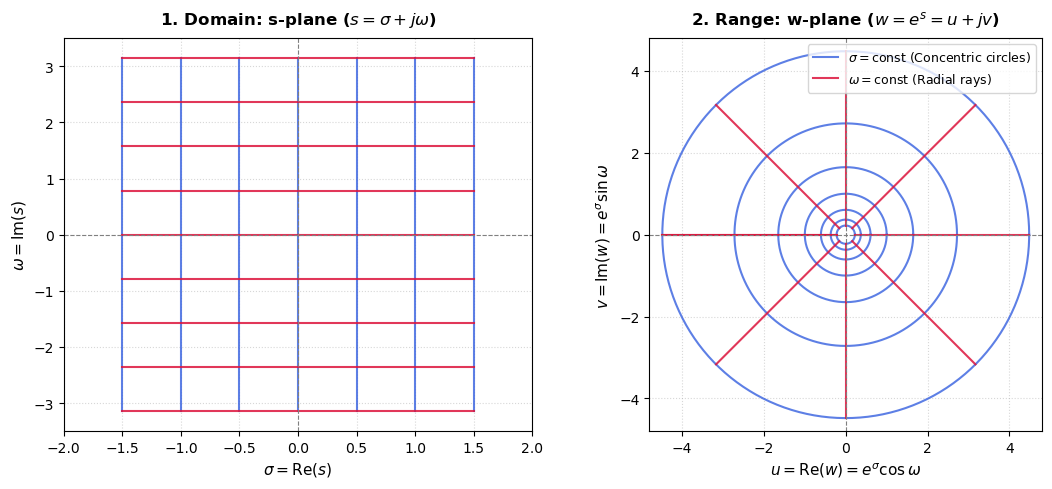

In [ ]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

sigmas = np.linspace(-1.5, 1.5, 7)
omegas = np.linspace(-np.pi, np.pi, 9)

# ---------------------------------------------------------
# 1. Domain: s-plane (s = sigma + j*omega)
# ---------------------------------------------------------
# sigma = const (수직선, 파란색)
for s_val in sigmas:
    w_vals = np.linspace(-np.pi, np.pi, 200)
    ax1.plot([s_val] * len(w_vals), w_vals, color='royalblue', lw=1.5, alpha=0.85)

# omega = const (수평선, 빨간색)
for w_val in omegas:
    s_vals = np.linspace(-1.5, 1.5, 200)
    ax1.plot(s_vals, [w_val] * len(s_vals), color='crimson', lw=1.5, alpha=0.85)

ax1.set_title("1. Domain: s-plane ($s = \\sigma + j\\omega$)", fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel(r"$\sigma = \mathrm{Re}(s)$", fontsize=11)
ax1.set_ylabel(r"$\omega = \mathrm{Im}(s)$", fontsize=11)
ax1.set_xlim(-2, 2)
ax1.set_ylim(-3.5, 3.5)
ax1.axhline(0, color='gray', lw=0.8, ls='--')
ax1.axvline(0, color='gray', lw=0.8, ls='--')
ax1.grid(True, linestyle=':', alpha=0.5)

# ---------------------------------------------------------
# 2. Range: w-plane (w = e^s = u + j*v)
# ---------------------------------------------------------
# sigma = const -> 동심원 (Concentric circles)
for s_val in sigmas:
    r = np.exp(s_val)
    theta = np.linspace(0, 2 * np.pi, 300)
    ax2.plot(
        r * np.cos(theta), r * np.sin(theta),
        color='royalblue', lw=1.5, alpha=0.85,
        label=r'$\sigma = \mathrm{const}$ (Concentric circles)' if s_val == sigmas[0] else ""
    )

# omega = const -> 방사선 (Radial rays)
for w_val in omegas:
    r_vals = np.exp(np.linspace(-1.5, 1.5, 200))
    ax2.plot(
        r_vals * np.cos(w_val), r_vals * np.sin(w_val),
        color='crimson', lw=1.5, alpha=0.85,
        label=r'$\omega = \mathrm{const}$ (Radial rays)' if w_val == omegas[0] else ""
    )

ax2.set_title("2. Range: w-plane ($w = e^s = u + jv$)", fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel(r"$u = \mathrm{Re}(w) = e^\sigma \cos\omega$", fontsize=11)
ax2.set_ylabel(r"$v = \mathrm{Im}(w) = e^\sigma \sin\omega$", fontsize=11)
ax2.set_xlim(-4.8, 4.8)
ax2.set_ylim(-4.8, 4.8)
ax2.set_aspect('equal')
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.axvline(0, color='gray', lw=0.8, ls='--')
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import plotly.graph_objects as go

# 그리드 데이터 생성: s = sigma + j*omega
sigma = np.linspace(-2.0, 1.5, 100)
omega = np.linspace(-2 * np.pi, 2 * np.pi, 150)
S, W = np.meshgrid(sigma, omega)

# e^s 의 실수부(u) 및 허수부(v)
# e^s = e^sigma * cos(omega) + j * e^sigma * sin(omega)
U = np.exp(S) * np.cos(W)   # z축 높이: Re(e^s)
V = np.exp(S) * np.sin(W)   # 표면 색상: Im(e^s)

# 3D Surface 생성
fig = go.Figure(
    data=[
        go.Surface(
            x=S,
            y=W,
            z=U,
            surfacecolor=V,          # 표면 색상을 허수부 값으로 매핑
            colorscale='Turbo',
            colorbar=dict(
                title=dict(text="Im(eˢ)", side="right"),
                thickness=18,
                len=0.75
            ),
            hovertemplate=(
                "<b>σ (Re)</b>: %{x:.2f}<br>"
                "<b>ω (Im)</b>: %{y:.2f} rad<br>"
                "<b>Re(eˢ)</b>: %{z:.2f}<br>"
                "<b>Im(eˢ)</b>: %{surfacecolor:.2f}"
                "<extra></extra>"
            ),
            contours=dict(
                z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True)
            )
        )
    ]
)

# 레이아웃 및 뷰 설정
fig.update_layout(
    title=dict(
        text="<b>Complex Exponential Function</b> : <i>w = eˢ (s = σ + jω)</i>",
        x=0.5,
        y=0.95
    ),
    width=900,
    height=750,
    template="plotly_white",
    scene=dict(
        xaxis=dict(title="σ = Re(s)", showgrid=True, gridcolor="lightgray"),
        yaxis=dict(title="ω = Im(s)", showgrid=True, gridcolor="lightgray"),
        zaxis=dict(title="Re(eˢ) = e^σ cos(ω)", showgrid=True, gridcolor="lightgray"),
        camera=dict(
            eye=dict(x=-1.6, y=-1.6, z=0.85)
        ),
        aspectratio=dict(x=1, y=1.2, z=0.7)
    ),
    margin=dict(l=20, r=20, t=50, b=20)
)

fig.show()